# Description

It explores the context/tissue/cell type of the top samples associated with an LV.

Follow the notebook instructions below.

# Modules

In [1]:
import re
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from data.recount2 import LVAnalysis
from utils import chunker
import conf

# Settings

Specify below the LV id you are interested in:

In [2]:
LV_NAME = "LV871"

# Paths

These are paths to folder and files where we'll save our figures.

In [3]:
OUTPUT_FIGURES_DIR = Path(conf.RESULTS_DIR, "demo", f"{LV_NAME.lower()}").resolve()
display(OUTPUT_FIGURES_DIR)
OUTPUT_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

PosixPath('/opt/data/results/demo/lv871')

In [4]:
OUTPUT_CELL_TYPE_FILEPATH = OUTPUT_FIGURES_DIR / f"{LV_NAME.lower()}-cell_types.svg"
display(OUTPUT_CELL_TYPE_FILEPATH)

PosixPath('/opt/data/results/demo/lv871/lv871-cell_types.svg')

# Load MultiPLIER summary

In [5]:
multiplier_model_summary = pd.read_pickle(conf.MULTIPLIER["MODEL_SUMMARY_FILE"])

In [6]:
multiplier_model_summary.shape

(2157, 5)

In [7]:
multiplier_model_summary.head()

,pathway,LV index,AUC,p-value,FDR
1,KEGG_LYSINE_DEGRADATION,1,0.388059,0.866078,0.956005
2,REACTOME_MRNA_SPLICING,1,0.733057,0.000048,0.000582
3,MIPS_NOP56P_ASSOCIATED_PRE_RRNA_COMPLEX,1,0.680555,0.001628,0.011366
4,KEGG_DNA_REPLICATION,1,0.549473,0.312155,0.539951
5,PID_MYC_ACTIVPATHWAY,1,0.639303,0.021702,0.083739


# Load LV data

You can use the `LVAnalysis` class to explore an LV.

In [8]:
lv_obj = LVAnalysis(LV_NAME)

Here I show the top 20 genes for our LV. You can see gene symbols, the LV weight (in column `LV603`) and the cytoband.

In [9]:
lv_obj.lv_genes.head(20)

,gene_name,LV871,gene_band
0,DSC1,4.629977,18q12.1
1,DSP,3.923222,6p24.3
2,CAPNS2,3.263323,16q12.2
3,ARG1,3.127015,6q23.2
4,RORA,2.997893,15q22.2
5,IDE,2.771529,10q23.33
6,GJB6,2.757826,13q12.11
7,TP63,2.630677,3q28
8,TMEM45A,2.517646,3q12.2
9,PERP,2.454113,6q23.3


Show the pathways our LV is aligned to (neutrophils):

In [10]:
multiplier_model_summary[
    multiplier_model_summary["LV index"].isin((LV_NAME[2:],))
    & (
        (multiplier_model_summary["FDR"] < 0.05)
        & (multiplier_model_summary["AUC"] >= 0.75)
    )
]

[2025-09-24 17:53:03,067 - numexpr.utils] INFO: Note: NumExpr detected 32 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 8.
[2025-09-24 17:53:03,067 - numexpr.utils] INFO: NumExpr defaulting to 8 threads.


,pathway,LV index,AUC,p-value,FDR


Here I load the LV metadata.
This is, for each sample from our matrix B, we load its metadata.
The `LVAnalysis` class takes care of downloading all necessary files from recount2.

In [11]:
lv_data = lv_obj.get_experiments_data()

SRP065812, SRP050971, SRP053794, SRP016583, SRP035988, SRP042161, SRP026042, SRP057087, SRP043085, SRP014320, SRP028180, SRP051182, SRP066834, SRP065445, SRP019807, SRP021891, SRP044925, SRP026333, SRP043388, SRP030401, SRP052856, SRP065219, SRP060416, SRP057196, 

/opt/code/libs/data/recount2.py:323: UserWarning: Not all experiments data could be loaded (23 != 24)
  warnings.warn(


In [12]:
lv_data.shape

(3302, 36)

In [13]:
lv_data.head()

subject status  \
project   run                             
SRP065812 SRR2926066  psoriasis patient   
          SRR2926067  psoriasis patient   
          SRR2926063  psoriasis patient   
          SRR2926064  psoriasis patient   
          SRR2926062  psoriasis patient   

                                                 time point  \
project   run                                                 
SRP065812 SRR2926066  after 1 month of adalimumab treatment   
          SRR2926067  after 1 month of adalimumab treatment   
          SRR2926063  after 1 month of adalimumab treatment   
          SRR2926064  after 1 month of adalimumab treatment   
          SRR2926062  after 1 month of adalimumab treatment   

                                               tissue type tissue gender  age  \
project   run                                                                   
SRP065812 SRR2926066  lesional skin from psoriasis patient    NaN    NaN  NaN   
          SRR2926067  lesional skin from psoriasis patient    NaN    NaN  NaN   
          SRR2926063  lesional skin from psoriasis patient    NaN    NaN  NaN   
          SRR2926064  lesional skin from psoriasis patient    NaN    NaN  NaN   
          SRR2926062  lesional skin from psoriasis patient    NaN    NaN  NaN   

                     patient group cell line cell type  ... tumor size  \
project   run                                           ...              
SRP065812 SRR2926066     NaN   NaN       NaN       NaN  ...        NaN   
          SRR2926067     NaN   NaN       NaN       NaN  ...        NaN   
          SRR2926063     NaN   NaN       NaN       NaN  ...        NaN   
          SRR2926064     NaN   NaN       NaN       NaN  ...        NaN   
          SRR2926062     NaN   NaN       NaN       NaN  ...        NaN   

                     tumor grade molecule subtype growth conditions passage  \
project   run                                                                 
SRP065812 SRR2926066         NaN              NaN               NaN     NaN   
          SRR2926067         NaN              NaN               NaN     NaN   
          SRR2926063         NaN              NaN               NaN     NaN   
          SRR2926064         NaN              NaN               NaN     NaN   
          SRR2926062         NaN              NaN               NaN     NaN   

                     tonsil donor facs gating c1 chip id  \
project   run                                              
SRP065812 SRR2926066          NaN         NaN        NaN   
          SRR2926067          NaN         NaN        NaN   
          SRR2926063          NaN         NaN        NaN   
          SRR2926064          NaN         NaN        NaN   
          SRR2926062          NaN         NaN        NaN   

                     experiment_sample_name     LV871  
project   run                                          
SRP065812 SRR2926066                    NaN  1.079310  
          SRR2926067                    NaN  1.228680  
          SRR2926063                    NaN  0.908809  
          SRR2926064                    NaN  1.200705  
          SRR2926062                    NaN  0.988928  

[5 rows x 36 columns]

# LV cell types analysis

## Get top attributes

Here I quickly show the top attributes in our metadata for which we have the largest LV variance.
This is just to have an idea of the variance across different attributes

In [14]:
lv_attrs = lv_obj.get_attributes_variation_score()
display(lv_attrs.head(20))

tissue type                                0.105922
subject status                             0.040947
disease state                              0.034051
age                                        0.031146
patient                                    0.028376
gender                                     0.027406
time point                                 0.024151
tissue                                     0.021516
group                                      0.019048
response to smoothened (smo) inhibitors    0.014489
tissue/treatment id                        0.014118
pathology                                  0.014075
patient cohort                             0.012041
treatment                                  0.011877
patient id                                 0.011189
subjects                                   0.010246
age of subjects                            0.010246
diagnosis                                  0.009920
differentiation day                        0.009386
cell line   

Since we are interested in cell types and tissues, the code below will find which attributes contain "cell type" or "tissue", so we can select from these results.

In [15]:
# show those with cell type or tissue in their name
_tmp = pd.Series(lv_attrs.index)
lv_attrs[
    _tmp.str.match(
        "(?:cell.*(type|line)$)|(?:tissue$)|(?:tissue.*type$)",
        case=False,
        flags=re.IGNORECASE,
    ).values
].sort_values(ascending=False)

tissue type    0.105922
tissue         0.021516
cell line      0.007668
cell type      0.003993
dtype: float64

Select from the output above those you are interested in. Usually all of them.

In [16]:
lv_attrs_selected = [
    "tissue type",
    "tissue",
    "cell line",
    "cell type",
]

In [17]:
_tmp = lv_data.loc[
    :,
    lv_attrs_selected + [LV_NAME],
]

In [18]:
_tmp_seq = list(chunker(_tmp.sort_values(LV_NAME, ascending=False), 25))

Now that we selected attributes that might be providing information about the cell type, we can see which are the top ones.

If you change the number in the cell below, you can paginate over the entire set of results; for example, with `_tmp_seq[1]` you'll see the next "page" in a descending order with respect to the LV value. So the ones at the top are the most important ones.

In [19]:
_tmp_seq[0]

tissue type tissue cell line  \
project   run                                                                 
SRP065812 SRR2926039  lesional skin from psoriasis patient    NaN       NaN   
          SRR2926065  lesional skin from psoriasis patient    NaN       NaN   
          SRR2926043  lesional skin from psoriasis patient    NaN       NaN   
          SRR2926036  lesional skin from psoriasis patient    NaN       NaN   
          SRR2926038  lesional skin from psoriasis patient    NaN       NaN   
          SRR2926035  lesional skin from psoriasis patient    NaN       NaN   
          SRR2926034  lesional skin from psoriasis patient    NaN       NaN   
          SRR2926060  lesional skin from psoriasis patient    NaN       NaN   
          SRR2926049  lesional skin from psoriasis patient    NaN       NaN   
          SRR2926050  lesional skin from psoriasis patient    NaN       NaN   
          SRR2926048  lesional skin from psoriasis patient    NaN       NaN   
          SRR2926067  lesional skin from psoriasis patient    NaN       NaN   
          SRR2926058  lesional skin from psoriasis patient    NaN       NaN   
          SRR2926064  lesional skin from psoriasis patient    NaN       NaN   
          SRR2926033  lesional skin from psoriasis patient    NaN       NaN   
          SRR2926061  lesional skin from psoriasis patient    NaN       NaN   
          SRR2926053  lesional skin from psoriasis patient    NaN       NaN   
          SRR2926055  lesional skin from psoriasis patient    NaN       NaN   
          SRR2926016                           normal skin    NaN       NaN   
          SRR2926051  lesional skin from psoriasis patient    NaN       NaN   
          SRR2926042  lesional skin from psoriasis patient    NaN       NaN   
          SRR2926020                           normal skin    NaN       NaN   
          SRR2926032  lesional skin from psoriasis patient    NaN       NaN   
          SRR2926052  lesional skin from psoriasis patient    NaN       NaN   
          SRR2926066  lesional skin from psoriasis patient    NaN       NaN   

                     cell type     LV871  
project   run                             
SRP065812 SRR2926039       NaN  1.417212  
          SRR2926065       NaN  1.405329  
          SRR2926043       NaN  1.381269  
          SRR2926036       NaN  1.377640  
          SRR2926038       NaN  1.333752  
          SRR2926035       NaN  1.288346  
          SRR2926034       NaN  1.276503  
          SRR2926060       NaN  1.270298  
          SRR2926049       NaN  1.269860  
          SRR2926050       NaN  1.248297  
          SRR2926048       NaN  1.238623  
          SRR2926067       NaN  1.228680  
          SRR2926058       NaN  1.213850  
          SRR2926064       NaN  1.200705  
          SRR2926033       NaN  1.197822  
          SRR2926061       NaN  1.176662  
          SRR2926053       NaN  1.168415  
          SRR2926055       NaN  1.150900  
          SRR2926016       NaN  1.134301  
          SRR2926051       NaN  1.120677  
          SRR2926042       NaN  1.117946  
          SRR2926020       NaN  1.100897  
          SRR2926032       NaN  1.090897  
          SRR2926052       NaN  1.081011  
          SRR2926066       NaN  1.079310

You can see above that the RNA-seq samples are from neutrophils or granulocytes.
If we move to the next "page", we'll see this:

In [20]:
_tmp_seq[1]

tissue type tissue cell line  \
project   run                                                                 
SRP065812 SRR2926059  lesional skin from psoriasis patient    NaN       NaN   
          SRR2926044  lesional skin from psoriasis patient    NaN       NaN   
          SRR2926037  lesional skin from psoriasis patient    NaN       NaN   
          SRR2926045  lesional skin from psoriasis patient    NaN       NaN   
          SRR2926057  lesional skin from psoriasis patient    NaN       NaN   
          SRR2926017                           normal skin    NaN       NaN   
          SRR2926041  lesional skin from psoriasis patient    NaN       NaN   
          SRR2926018                           normal skin    NaN       NaN   
          SRR2926026                           normal skin    NaN       NaN   
          SRR2926019                           normal skin    NaN       NaN   
          SRR2926046  lesional skin from psoriasis patient    NaN       NaN   
          SRR2926062  lesional skin from psoriasis patient    NaN       NaN   
          SRR2926025                           normal skin    NaN       NaN   
          SRR2926023                           normal skin    NaN       NaN   
          SRR2926047  lesional skin from psoriasis patient    NaN       NaN   
          SRR2926054  lesional skin from psoriasis patient    NaN       NaN   
          SRR2926027                           normal skin    NaN       NaN   
          SRR2926063  lesional skin from psoriasis patient    NaN       NaN   
          SRR2926021                           normal skin    NaN       NaN   
          SRR2926040  lesional skin from psoriasis patient    NaN       NaN   
          SRR2926029                           normal skin    NaN       NaN   
          SRR2926031                           normal skin    NaN       NaN   
SRP050971 SRR1698178                        psoriatic skin    NaN       NaN   
SRP065812 SRR2926022                           normal skin    NaN       NaN   
          SRR2926056  lesional skin from psoriasis patient    NaN       NaN   

                     cell type     LV871  
project   run                             
SRP065812 SRR2926059       NaN  1.060313  
          SRR2926044       NaN  1.057645  
          SRR2926037       NaN  1.049331  
          SRR2926045       NaN  1.045528  
          SRR2926057       NaN  1.031322  
          SRR2926017       NaN  1.027990  
          SRR2926041       NaN  1.019522  
          SRR2926018       NaN  1.014277  
          SRR2926026       NaN  1.011358  
          SRR2926019       NaN  1.008718  
          SRR2926046       NaN  1.008308  
          SRR2926062       NaN  0.988928  
          SRR2926025       NaN  0.980794  
          SRR2926023       NaN  0.977687  
          SRR2926047       NaN  0.973959  
          SRR2926054       NaN  0.945440  
          SRR2926027       NaN  0.930887  
          SRR2926063       NaN  0.908809  
          SRR2926021       NaN  0.878975  
          SRR2926040       NaN  0.848054  
          SRR2926029       NaN  0.835109  
          SRR2926031       NaN  0.817093  
SRP050971 SRR1698178       NaN  0.812073  
SRP065812 SRR2926022       NaN  0.811113  
          SRR2926056       NaN  0.799450

Although the attributes we selected (`cell type`, `celltype` and `tissue`) seem to be enough for most of the RNA-seq samples to get their cell types, this is not the case for some of them. For example, we have empty values (NaN) for `SRP015360`.

You can explore the metadata provided for a particular SPR with the code below. Let's see what we have in `SRP015360`:

In [21]:
# list the top 10 samples from this project
lv_data.loc[["SRP035864"]].dropna(how="all", axis=1).sort_values(
    LV_NAME, ascending=False
).head(10)

KeyError: "['SRP035864'] not in index"

So for `SRP015360` we only have three attributes: `age`, `Sex` and `treatment`. No cell type information. Here you can start grasping the challenges in analyzing this data.

If you are really interested in this metadata for this project, you can use this URL:
```
https://trace.ncbi.nlm.nih.gov/Traces/sra/?study=SRP015360
```
where you can put the SRP code you want. If you check the URL above, you'll see that these samples were taken from neutrophils as well (treated with different stimuli), although we don't have metadata about the cell type/tissue.

Ok, we do not want several attributes conveying the same information (cell types), just a single one, so here we'll combine the attributes we found before with a particular _order_.
In this case I select `cell type` _first_ (the order is important), `celltype` as second, and `tissue` as third/last.
This means that I will use the information in `cell type` first, but if this is empty (as in `SRP045500`), we'll try with `celltype`, and so on.

In [22]:
SELECTED_ATTRIBUTES = [
    "tissue type",
    "tissue",
    "cell line",
    "cell type",
]

## Get a single attribute with "cell type/tissue" information

In [23]:
plot_data = lv_data.loc[:, SELECTED_ATTRIBUTES + [LV_NAME]]

In [24]:
# if blank/nan, fill cell type column with tissue content
_new_column = plot_data[SELECTED_ATTRIBUTES].fillna(method="backfill", axis=1)[
    SELECTED_ATTRIBUTES[0]
]
plot_data[SELECTED_ATTRIBUTES[0]] = _new_column
plot_data = plot_data.drop(columns=SELECTED_ATTRIBUTES[1:])
plot_data = plot_data.fillna({SELECTED_ATTRIBUTES[0]: "NOT CATEGORIZED"})

In [25]:
plot_data = plot_data.sort_values(LV_NAME, ascending=False)

In [26]:
plot_data.head(20)

tissue type     LV871
project   run                                                       
SRP065812 SRR2926039  lesional skin from psoriasis patient  1.417212
          SRR2926065  lesional skin from psoriasis patient  1.405329
          SRR2926043  lesional skin from psoriasis patient  1.381269
          SRR2926036  lesional skin from psoriasis patient  1.377640
          SRR2926038  lesional skin from psoriasis patient  1.333752
          SRR2926035  lesional skin from psoriasis patient  1.288346
          SRR2926034  lesional skin from psoriasis patient  1.276503
          SRR2926060  lesional skin from psoriasis patient  1.270298
          SRR2926049  lesional skin from psoriasis patient  1.269860
          SRR2926050  lesional skin from psoriasis patient  1.248297
          SRR2926048  lesional skin from psoriasis patient  1.238623
          SRR2926067  lesional skin from psoriasis patient  1.228680
          SRR2926058  lesional skin from psoriasis patient  1.213850
          SRR2926064  lesional skin from psoriasis patient  1.200705
          SRR2926033  lesional skin from psoriasis patient  1.197822
          SRR2926061  lesional skin from psoriasis patient  1.176662
          SRR2926053  lesional skin from psoriasis patient  1.168415
          SRR2926055  lesional skin from psoriasis patient  1.150900
          SRR2926016                           normal skin  1.134301
          SRR2926051  lesional skin from psoriasis patient  1.120677

You can see that now all attributes ("celltype", "cell type" and "tissue") are combined under a single attribute named "cell type".
For example, if you look at `SRP045500`, which had a value under "celltype" but an empty (NaN) value for attribute "cell type", that now the value was moved to "cell type" (it was unified into this single attribute).

If you see "NOT CATEGORIZED", it means that none of the attributes you used had a value (they were all empty or NaN). In this case you would go the URL before and read the article/RNA-seq data description to find out the cell type or tissue (or whatever attribute your are interested in).

## Standardize cell type names

When cell type values are different but represent the same cell type, we unify them:

In [27]:
final_plot_data = plot_data.replace(
    {
        SELECTED_ATTRIBUTES[0]: {
            # # neutrophils:
            # "primary human neutrophils": "Neutrophils",
            # "Neutrophil isolated from peripheral blood": "Neutrophils",
            # "Neutrophil": "Neutrophils",
            # "neutrophils (Neu)": "Neutrophils",
            # # granulocytes:
            # "granulocyte": "Granulocytes",
            # # monocytes:
            # "primary human monocytes": "Monocytes",
            # # whole blood:
            # #             "whole blood": "Whole blood",  # uncomment this line to merge occurences of "whole blood" into "Whole blood"
            # "Whole Blood": "Whole blood",
            # # PBMC:
            # "primary human PBMC": "PBMC",
            # # B-cells:
            # "primary human B cells": "B cells",
            # # T-cells:
            # "primary human T cells": "T cells",
            # # epithelial cells:
            # "epithelial cells (Epi)": "Epithelial cells",
            # "primary human myeloid DC": "mDCs",
        }
    }
)

The code below is more advanced, but you can use it to customize even further your final attribute value (for example, if you want to use the cell type, but put the treatment name with parenthesis).

In [28]:
# # add also tissue information to these projects
# _srp_code = "SRP061881"
# _tmp = final_plot_data.loc[(_srp_code,)].apply(
#     lambda x: lv_data.loc[(_srp_code, x.name), "cell type"]
#     + f" ({lv_data.loc[(_srp_code, x.name), 'tissue']})",
#     axis=1,
# )
# final_plot_data.loc[(_srp_code, _tmp.index), SELECTED_ATTRIBUTES[0]] = _tmp.values

In [29]:
# # all samples from SRP015360 are neutrophils
# final_plot_data[SELECTED_ATTRIBUTES[0]] = final_plot_data.apply(
#     lambda x: "Neutrophils" if x.name[0] in ("SRP015360",) else x[SELECTED_ATTRIBUTES[0]],
#     axis=1,
# )

In [30]:
final_plot_data = final_plot_data.sort_values(LV_NAME, ascending=False)

## Threshold LV values

The code below is useful in case you want to put a threshold to the plot (for example, you have same samples with very high values).

In [31]:
# final_plot_data.loc[
#     final_plot_data[LV_NAME] > LV_AXIS_THRESHOLD, LV_NAME
# ] = LV_AXIS_THRESHOLD

## Delete samples with no tissue/cell type information

If you are not interested in samples for which we couldn't find cell type/tissue information, you can delete them by uncommenting the code below.
However, if you want, you can take a look at those later (we'll show you how at the end).

In [32]:
# final_plot_data = final_plot_data[
#     final_plot_data[SELECTED_ATTRIBUTE] != "NOT CATEGORIZED"
# ]

## Set top cell types to show

In [33]:
N_TOP_ATTRS = 10

In [34]:
attr_order = (
    final_plot_data.groupby(SELECTED_ATTRIBUTES[0])
    .max()
    .sort_values(LV_NAME, ascending=False)
    .index[:N_TOP_ATTRS]
    .tolist()
)

In [35]:
len(attr_order)

10

In [36]:
attr_order[:5]

['lesional skin from psoriasis patient',
 'normal skin',
 'psoriatic skin',
 'lesional skin',
 'skin']

# Plot

Now we create the plot with RNA-seq samples as points, cell types in the x-axis, and the LV value in the y-axis.
This shows you in which cell types genes in LV603 are primirily expressed.

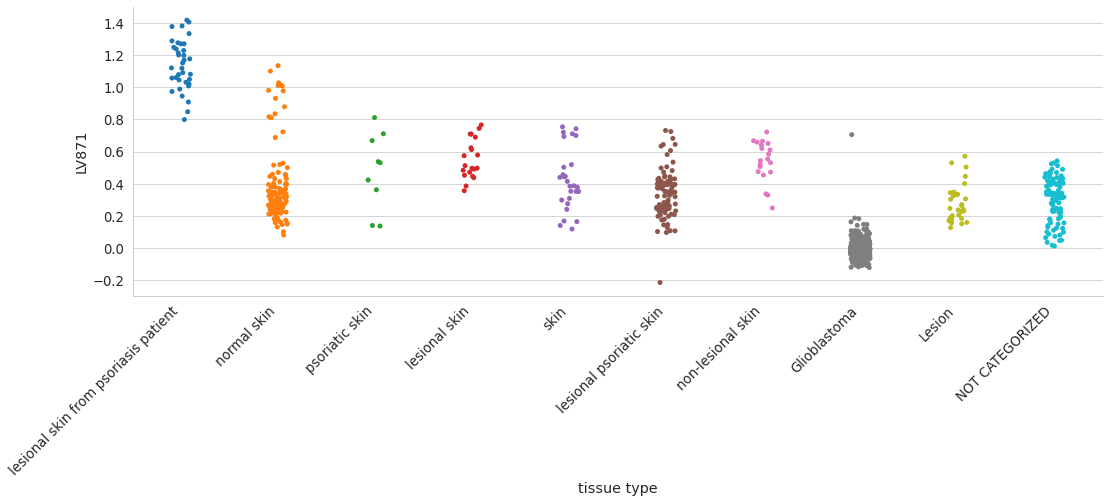

In [37]:
with sns.plotting_context("paper", font_scale=1.5), sns.axes_style("whitegrid"):
    sns.catplot(
        data=final_plot_data,
        y=LV_NAME,
        x=SELECTED_ATTRIBUTES[0],
        order=attr_order,
        kind="strip",
        height=5,
        aspect=3,
    )
    plt.xticks(rotation=45, horizontalalignment="right")

    # You can save the figure if you uncomment the code below
    # the figure will be created under ${DATA_FOLDER}/results/demo

    plt.savefig(
        OUTPUT_CELL_TYPE_FILEPATH,
        bbox_inches="tight",
        facecolor="white",
    )

# Debug

Now that you have the figure for your LV, you can debug some things.
For example, you'll see above that some samples are "NOT CATEGORIZED".
Let's see which are those:

In [38]:
with pd.option_context(
    "display.max_rows", None, "display.max_columns", None, "display.max_colwidth", None
):
    _tmp = final_plot_data[
        final_plot_data[SELECTED_ATTRIBUTES[0]].str.contains("lesional skin")
    ]
    display(_tmp.head(20))

tissue type     LV871
project   run                                                       
SRP065812 SRR2926039  lesional skin from psoriasis patient  1.417212
          SRR2926065  lesional skin from psoriasis patient  1.405329
          SRR2926043  lesional skin from psoriasis patient  1.381269
          SRR2926036  lesional skin from psoriasis patient  1.377640
          SRR2926038  lesional skin from psoriasis patient  1.333752
          SRR2926035  lesional skin from psoriasis patient  1.288346
          SRR2926034  lesional skin from psoriasis patient  1.276503
          SRR2926060  lesional skin from psoriasis patient  1.270298
          SRR2926049  lesional skin from psoriasis patient  1.269860
          SRR2926050  lesional skin from psoriasis patient  1.248297
          SRR2926048  lesional skin from psoriasis patient  1.238623
          SRR2926067  lesional skin from psoriasis patient  1.228680
          SRR2926058  lesional skin from psoriasis patient  1.213850
          SRR2926064  lesional skin from psoriasis patient  1.200705
          SRR2926033  lesional skin from psoriasis patient  1.197822
          SRR2926061  lesional skin from psoriasis patient  1.176662
          SRR2926053  lesional skin from psoriasis patient  1.168415
          SRR2926055  lesional skin from psoriasis patient  1.150900
          SRR2926051  lesional skin from psoriasis patient  1.120677
          SRR2926042  lesional skin from psoriasis patient  1.117946

We don't have information about cell type/tissue for these.
But we can manually go to the URL showed before and check out.
For example, for `SRP015360` we can open our browser with this URL:
https://trace.ncbi.nlm.nih.gov/Traces/sra/?study=SRP065812, and see that the samples were taken from neutrophils.

If you need to see which information is provided by each SRP, you can again use the code below:

In [39]:
# what is there in these projects?
lv_data.loc[["SRP065812"]].dropna(how="all", axis=1).sort_values(
    LV_NAME, ascending=False
).head(60)

subject status  \
project   run                             
SRP065812 SRR2926039  psoriasis patient   
          SRR2926065  psoriasis patient   
          SRR2926043  psoriasis patient   
          SRR2926036  psoriasis patient   
          SRR2926038  psoriasis patient   
          SRR2926035  psoriasis patient   
          SRR2926034  psoriasis patient   
          SRR2926060  psoriasis patient   
          SRR2926049  psoriasis patient   
          SRR2926050  psoriasis patient   
          SRR2926048  psoriasis patient   
          SRR2926067  psoriasis patient   
          SRR2926058  psoriasis patient   
          SRR2926064  psoriasis patient   
          SRR2926033  psoriasis patient   
          SRR2926061  psoriasis patient   
          SRR2926053  psoriasis patient   
          SRR2926055  psoriasis patient   
          SRR2926016    healthy control   
          SRR2926051  psoriasis patient   
          SRR2926042  psoriasis patient   
          SRR2926020    healthy control   
          SRR2926032  psoriasis patient   
          SRR2926052  psoriasis patient   
          SRR2926066  psoriasis patient   
          SRR2926059  psoriasis patient   
          SRR2926044  psoriasis patient   
          SRR2926037  psoriasis patient   
          SRR2926045  psoriasis patient   
          SRR2926057  psoriasis patient   
          SRR2926017    healthy control   
          SRR2926041  psoriasis patient   
          SRR2926018    healthy control   
          SRR2926026    healthy control   
          SRR2926019    healthy control   
          SRR2926046  psoriasis patient   
          SRR2926062  psoriasis patient   
          SRR2926025    healthy control   
          SRR2926023    healthy control   
          SRR2926047  psoriasis patient   
          SRR2926054  psoriasis patient   
          SRR2926027    healthy control   
          SRR2926063  psoriasis patient   
          SRR2926021    healthy control   
          SRR2926040  psoriasis patient   
          SRR2926029    healthy control   
          SRR2926031    healthy control   
          SRR2926022    healthy control   
          SRR2926056  psoriasis patient   
          SRR2926024    healthy control   
          SRR2926030    healthy control   
          SRR2926028    healthy control   

                                                 time point  \
project   run                                                 
SRP065812 SRR2926039            before adalimumab treatment   
          SRR2926065  after 1 month of adalimumab treatment   
          SRR2926043            before adalimumab treatment   
          SRR2926036            before adalimumab treatment   
          SRR2926038            before adalimumab treatment   
          SRR2926035            before adalimumab treatment   
          SRR2926034            before adalimumab treatment   
          SRR2926060  after 1 month of adalimumab treatment   
          SRR2926049            before adalimumab treatment   
          SRR2926050  after 1 month of adalimumab treatment   
          SRR2926048            before adalimumab treatment   
          SRR2926067  after 1 month of adalimumab treatment   
          SRR2926058  after 1 month of adalimumab treatment   
          SRR2926064  after 1 month of adalimumab treatment   
          SRR2926033            before adalimumab treatment   
          SRR2926061  after 1 month of adalimumab treatment   
          SRR2926053  after 1 month of adalimumab treatment   
          SRR2926055  after 1 month of adalimumab treatment   
          SRR2926016                                    NaN   
          SRR2926051  after 1 month of adalimumab treatment   
          SRR2926042            before adalimumab treatment   
          SRR2926020                                    NaN   
          SRR2926032            before adalimumab treatment   
          SRR2926052  after 1 month of adalimumab treatment   
          SRR2926066  after 1 month of adalimumab treatment   
 

Now you can go back to section `Standardize cell type names` in this notebook and adjust according to this findings to improve the figure.
Once you are happy, you can remove the `NOT CATEGORIZED` items by uncommenting the code in `Delete samples with no tissue/cell type information`.